# Analisis Tutupan Lahan Sawah dan Non-Sawah

Tahapan analisis menggunakan citra Sentinel-2A Level-2A yang diambil melalui
openEO dalam bentuk file GeoTIFF (`.tif`). Citra tersebut digunakan untuk
mengambil nilai spektral berdasarkan titik-titik sampel yang sudah ditentukan.

Data referensi terdiri dari 100 sampel, yaitu 50 sampel Sawah dan 50 sampel
Non-Sawah. Seluruh titik telah diberi label berdasarkan hasil penentuan objek
menggunakan QGIS. Data nilai spektral dari masing-masing sampel kemudian
dimanfaatkan untuk proses klasifikasi biner dengan dua kategori, yaitu Sawah
dan Non-Sawah.

In [9]:
pip install geopandas

In [ ]:
pip install openeo

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 357.0/357.0 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 9.9 MB/s eta 0:00:00
  Attempting uninstall: xarray
    Found existing installation: xarray 2025.12.0
    Uninstalling xarray-2025.12.0:
      Successfully uninstalled xarray-2025.12.0


In [ ]:
%pip install scikit-learn

## 1. Pembentukan Data Ground Truth


Dataset *ground truth* dibangun melalui proses pengambilan sampel secara spasial.
Sampel dibagi ke dalam dua kategori utama, yaitu sawah dan non-sawah,
dengan jumlah data yang sama pada setiap kategori agar menghasilkan dataset yang seimbang.

| Target | Label | Sampel | Deskripsi |
|---|---:|---:|---|
| Sawah | `1` | 50 | Wilayah yang teridentifikasi sebagai lahan pertanian padi, mencakup kondisi vegetatif, area dengan genangan air/tanaman, hingga fase pematangan. |
| Non-Sawah | `0` | 50 | Wilayah yang tidak termasuk lahan sawah, seperti kawasan permukiman, bangunan, jalan, perairan permanen, dan vegetasi selain pertanian. |
| Keseluruhan | — | 100 | Seluruh objek sampel dikombinasikan ke dalam satu `GeoDataFrame` menggunakan sistem koordinat EPSG:4326. |



In [14]:
import geopandas as gpd
import openeo
import pandas as pd
from google.colab import files

# ==============================================================================
# 1. BACA KEDUA FILE ZIP (SAWAH & NON-SAWAH) DAN BERI LABEL OTOMATIS
# ==============================================================================

# Pilih file ZIP sawah
print("Pilih file ZIP Sawah:")
uploaded_sawah = files.upload()
nama_sawah = next(iter(uploaded_sawah))

# Pilih file ZIP non-sawah
print("Pilih file ZIP Non-Sawah:")
uploaded_nonsawah = files.upload()
nama_nonsawah = next(iter(uploaded_nonsawah))

gdf_sawah = gpd.read_file(nama_sawah).to_crs("EPSG:4326")
gdf_nonsawah = gpd.read_file(nama_nonsawah).to_crs("EPSG:4326")

# Beri kolom label secara otomatis
gdf_sawah["label_teks"] = "Sawah"
gdf_sawah["label"] = 1

gdf_nonsawah["label_teks"] = "Non-Sawah"
gdf_nonsawah["label"] = 0

# Gabungkan keduanya menjadi 1 GeoDataFrame (50 + 50 = 100 sampel)
gdf_gabungan = gpd.GeoDataFrame(
    pd.concat([gdf_sawah, gdf_nonsawah], ignore_index=True), crs="EPSG:4326"
)

print(f"Jumlah sampel Sawah     : {len(gdf_sawah)}")
print(f"Jumlah sampel Non-Sawah : {len(gdf_nonsawah)}")
print(f"Total sampel gabungan   : {len(gdf_gabungan)}")

# ==============================================================================
# 2. AMBIL BATAS KOORDINAT GABUNGAN (BOUNDING BOX) UNTUK OPENEO
# ==============================================================================
minx, miny, maxx, maxy = gdf_gabungan.total_bounds
buffer_deg = 0.005  # Tambahan margin ~500 meter agar titik di tepi tetap masuk

bbox = {
    "west": float(minx - buffer_deg),
    "south": float(miny - buffer_deg),
    "east": float(maxx + buffer_deg),
    "north": float(maxy + buffer_deg),
}
print("Bounding Box Gabungan:", bbox)

# ==============================================================================
# 3. KONEKSI KE OPENEO & UNDUH SENTINEL-2A FORMAT GEOTIFF (.tif)
# ==============================================================================
conn = openeo.connect("openeo.dataspace.copernicus.eu")
conn.authenticate_oidc()

datacube = conn.load_collection(
    "SENTINEL2_L2A",
    spatial_extent=bbox,
    temporal_extent=["2026-05-01", "2026-09-30"],  # Rentang waktu minim awan
    bands=[
        "B02",
        "B03",
        "B04",
        "B08",
        "B11",
    ],  # Blue, Green, Red, NIR, SWIR
    max_cloud_cover=10,
)

# Ambil median waktu agar bebas tutupan awan
composite_s2 = datacube.median_time()

# Unduh menjadi file GeoTIFF (.tif)
nama_tif = "sentinel2_sawah_nonsawah.tif"
print("Mengunduh citra Sentinel-2A (.tif)...")
composite_s2.download(nama_tif, format="GTiff")
print(f"Berhasil diunduh: {nama_tif}")

Pilih file ZIP Sawah:


Saving sawah.zip to sawah (2).zip
Pilih file ZIP Non-Sawah:


Saving non_sawah.zip to non_sawah (2).zip
Jumlah sampel Sawah     : 50
Jumlah sampel Non-Sawah : 51
Total sampel gabungan   : 101
Bounding Box Gabungan: {'west': 113.8758596, 'south': -7.0621674, 'east': 113.9495979, 'north': -6.9974734000000005}
Authenticated using refresh token.
Mengunduh citra Sentinel-2A (.tif)...
Berhasil diunduh: sentinel2_sawah_nonsawah.tif


## 2. Ekstraksi Fitur Spektral Sentinel-2A

Citra Sentinel-2A Level-2A diperoleh melalui openEO menggunakan
*bounding box* dari 100 titik sampel. Citra dengan tutupan awan maksimal 10%
digabungkan menggunakan `median_time()` dan disimpan dalam format GeoTIFF (`.tif`).

 Fitur yang Digunakan

- B02 (Blue) – informasi permukaan dan atmosfer.
- B03 (Green) – karakteristik vegetasi.
- B04 (Red) – penyerapan cahaya oleh vegetasi.
- B08 (NIR) – mendeteksi kondisi dan kerapatan vegetasi.
- B11 (SWIR) – informasi kelembapan dan kandungan air.

 Indeks Spektral

NDVI untuk mengetahui tingkat kehijauan vegetasi:

$$
NDVI = \frac{B08-B04}{B08+B04}
$$

NDWI untuk mengetahui kondisi air atau kelembapan:

$$
NDWI = \frac{B03-B08}{B03+B08}
$$

Fitur B02, B03, B04, B08, B11, NDVI, dan NDWI selanjutnya digunakan sebagai
input dalam proses klasifikasi Sawah dan Non-Sawah.

In [17]:
import numpy as np
import rasterio
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from google.colab import files

# 1. Buka file .tif Sentinel-2A dan samakan proyeksi koordinat (CRS)
with rasterio.open("sentinel2_sawah_nonsawah.tif") as src:
  gdf_projected = gdf_gabungan.to_crs(src.crs)

  # Ambil titik tengah (centroid) dari tiap sampel (mendukung Point maupun Polygon)
  koordinat_sampel = [
      (geom.centroid.x, geom.centroid.y) for geom in gdf_projected.geometry
  ]

  # Ekstrak nilai piksel dari kelima band Sentinel-2A
  nilai_band = list(src.sample(koordinat_sampel))

# 2. Buat tabel DataFrame Fitur
df_dataset = pd.DataFrame(nilai_band, columns=["B02", "B03", "B04", "B08", "B11"])

# 3. Tambahkan fitur indeks vegetasi (NDVI) & indeks air (NDWI)
df_dataset["NDVI"] = (df_dataset["B08"] - df_dataset["B04"]) / (
    df_dataset["B08"] + df_dataset["B04"] + 1e-6
)
df_dataset["NDWI"] = (df_dataset["B03"] - df_dataset["B08"]) / (
    df_dataset["B03"] + df_dataset["B08"] + 1e-6
)

# 4. Masukkan Koordinat & Label Kelas (Sawah = 1, Non-Sawah = 0)
df_dataset["Longitude"] = gdf_gabungan.geometry.centroid.x
df_dataset["Latitude"] = gdf_gabungan.geometry.centroid.y
df_dataset["Kelas"] = gdf_gabungan["label_teks"]
df_dataset["Target"] = gdf_gabungan["label"]

# Simpan ke CSV (bisa dipakai juga kalau mau diolah di KNIME)
nama_csv = "dataset_100sampel_sawah_nonsawah.csv"

df_dataset.to_csv(nama_csv, index=False)

print("Dataset berhasil disimpan ke:", nama_csv)

display(df_dataset.head())

# Otomatis download CSV agar bisa dibuka di Excel
files.download(nama_csv)

# ==============================================================================
# 5. PROSES KLASIFIKASI 2 KELAS (SAWAH VS NON-SAWAH)
# ==============================================================================

fitur_kolom = ["B02", "B03", "B04", "B08", "B11", "NDVI", "NDWI"]
X = df_dataset[fitur_kolom]
y = df_dataset["Kelas"]

# Split 80% Training (40 Sawah + 40 Non-Sawah) & 20% Testing (10 Sawah + 10 Non-Sawah)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Latih model Random Forest
model_rf = RandomForestClassifier(n_estimators=100, random_state=42)
model_rf.fit(X_train, y_train)

# Evaluasi pada data uji
y_pred = model_rf.predict(X_test)

print(
    "\n=== HASIL EVALUASI KLASIFIKASI 2 KELAS ==="
)

print(f"Akurasi Testing : {accuracy_score(y_test, y_pred) * 100:.2f}%")

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

print("\nClassification Report:\n", classification_report(y_test, y_pred))

Dataset berhasil disimpan ke: dataset_100sampel_sawah_nonsawah.csv


/tmp/ipykernel_432/3591193644.py:32: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  df_dataset["Longitude"] = gdf_gabungan.geometry.centroid.x
/tmp/ipykernel_432/3591193644.py:33: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  df_dataset["Latitude"] = gdf_gabungan.geometry.centroid.y


,B02,B03,B04,B08,B11,NDVI,NDWI,Longitude,Latitude,Kelas,Target
0,686,1065,855,3658,2986,0.621095,-0.549015,113.883082,-7.003927,Sawah,1
1,858,1275,1429,3469,3514,0.416497,-0.462479,113.883989,-7.003860,Sawah,1
2,740,1171,1230,3374,3366,0.465682,-0.484708,113.883452,-7.004368,Sawah,1
3,845,1135,1082,3443,3484,0.521768,-0.504150,113.884263,-7.004823,Sawah,1
4,1023,1397,1497,3135,3513,0.353627,-0.383495,113.885005,-7.004007,Sawah,1


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


=== HASIL EVALUASI KLASIFIKASI 2 KELAS ===
Akurasi Testing : 100.00%

Confusion Matrix:
 [[11  0]
 [ 0 10]]

Classification Report:
               precision    recall  f1-score   support

   Non-Sawah       1.00      1.00      1.00        11
       Sawah       1.00      1.00      1.00        10

    accuracy                           1.00        21
   macro avg       1.00      1.00      1.00        21
weighted avg       1.00      1.00      1.00        21



In [18]:
pip install seaborn

## 3. Evaluasi Model Random Forest untuk Klasifikasi Sawah

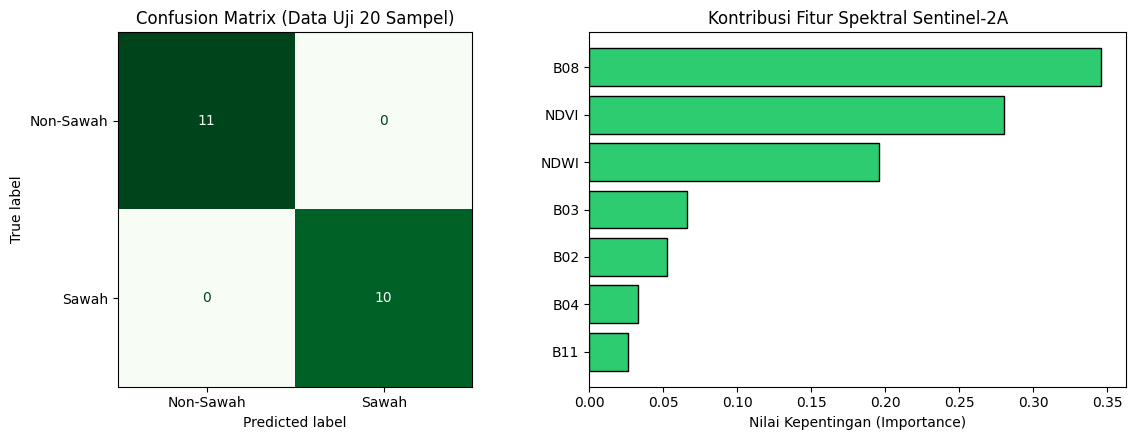

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


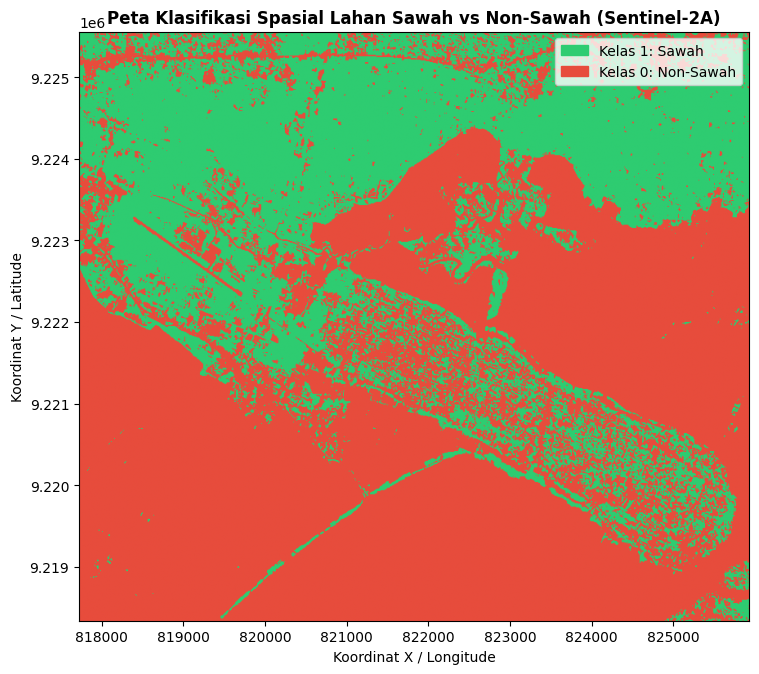

In [19]:
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import rasterio
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay

# ==============================================================================
# A. VISUALISASI CONFUSION MATRIX & FEATURE IMPORTANCE
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# 1. Plot Confusion Matrix
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, cmap="Greens", ax=axes[0], colorbar=False
)
axes[0].set_title("Confusion Matrix (Data Uji 20 Sampel)")

# 2. Plot Tingkat Kepentingan Fitur (Band & Indeks Spektral)
importances = model_rf.feature_importances_
indices = np.argsort(importances)
axes[1].barh(
    range(len(indices)),
    importances[indices],
    color="#2ecc71",
    edgecolor="black",
)
axes[1].set_yticks(range(len(indices)))
axes[1].set_yticklabels([fitur_kolom[i] for i in indices])
axes[1].set_xlabel("Nilai Kepentingan (Importance)")
axes[1].set_title("Kontribusi Fitur Spektral Sentinel-2A")

plt.tight_layout()
plt.savefig("evaluasi_klasifikasi_sawah.png", dpi=300)
plt.show()

# ==============================================================================
# B. KLASIFIKASI SELURUH PIKSEL CITRA (.TIF) MENJADI PETA SAWAH VS NON-SAWAH
# ==============================================================================
with rasterio.open("sentinel2_sawah_nonsawah.tif") as src:
  img = src.read()  # Shape: (5 bands, height, width)
  profil_raster = src.profile
  bounds = src.bounds

# Ambil masing-masing band (B02, B03, B04, B08, B11)
b02, b03, b04, b08, b11 = (
    img[0].astype(float),
    img[1].astype(float),
    img[2].astype(float),
    img[3].astype(float),
    img[4].astype(float),
)

# Hitung NDVI dan NDWI untuk seluruh piksel di citra .tif
ndvi_map = (b08 - b04) / (b08 + b04 + 1e-6)
ndwi_map = (b03 - b08) / (b03 + b08 + 1e-6)

# Susun seluruh piksel menjadi matriks 2D (baris = piksel, kolom = 7 fitur)
stack_fitur = np.stack([b02, b03, b04, b08, b11, ndvi_map, ndwi_map], axis=-1)
h, w, c = stack_fitur.shape
piksel_2d = np.nan_to_num(stack_fitur.reshape(-1, c), nan=0.0)

# Prediksi seluruh piksel menggunakan model Random Forest yang sudah dilatih
prediksi_label = model_rf.predict(piksel_2d)

# Ubah hasil prediksi ('Sawah' -> 1, 'Non-Sawah' -> 0) kembali ke ukuran gambar 2D (h, w)
peta_biner = np.where(prediksi_label == "Sawah", 1, 0).reshape(h, w)

# Tampilkan Peta Hasil Klasifikasi Spasial
plt.figure(figsize=(9, 7))
cmap_sawah = mcolors.ListedColormap(["#e74c3c", "#2ecc71"])  # Merah & Hijau
plt.imshow(
    peta_biner,
    cmap=cmap_sawah,
    extent=[bounds.left, bounds.right, bounds.bottom, bounds.top],
)

# Legenda Peta
patch_sawah = mpatches.Patch(color="#2ecc71", label="Kelas 1: Sawah")
patch_nonsawah = mpatches.Patch(color="#e74c3c", label="Kelas 0: Non-Sawah")
plt.legend(handles=[patch_sawah, patch_nonsawah], loc="upper right")
plt.title(
    "Peta Klasifikasi Spasial Lahan Sawah vs Non-Sawah (Sentinel-2A)",
    fontsize=12,
    fontweight="bold",
)
plt.xlabel("Koordinat X / Longitude")
plt.ylabel("Koordinat Y / Latitude")
plt.tight_layout()
plt.savefig("peta_klasifikasi_raster_sawah.png", dpi=300)
plt.show()